# Data exploration of the raw dataset

The goal of this notebook is to explore the dataset and find connections that can help us with feature engineering and preprocessing to improve training on tree-based models and other machine learning models. 

## Dataset strengths and weaknesses for XGBoost / MLP modeling

This notebook cell section performs an exploratory data analysis (EDA) on `data/horseData.csv` and produces charts that highlight potential strengths and weaknesses for tree-based (XGBoost) and neural MLP modeling.

/var/folders/m6/wqgw_v5x3tq4t4q1zm2fc5f80000gn/T/ipykernel_5365/1629813008.py:10: DtypeWarning: Columns (17,22) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(path)


Shape: (69709, 24)
Numeric features: ['rating', 'rawErg', 'erg', 'ems', 'grade', 'yob', 'fee', 'crop', 'ems3', 'price', 'lot', 'prev. price']
Missing values (top 20):
 prev. price    61237
purchaser      15850
fee               98
lot                9
form2              0
vendor             0
code               0
status             0
price              0
bmSire             0
grade4             0
ems3               0
name               0
form               0
crop               0
sire               0
sex                0
yob                0
grade              0
ems                0
dtype: int64

Sample rows:


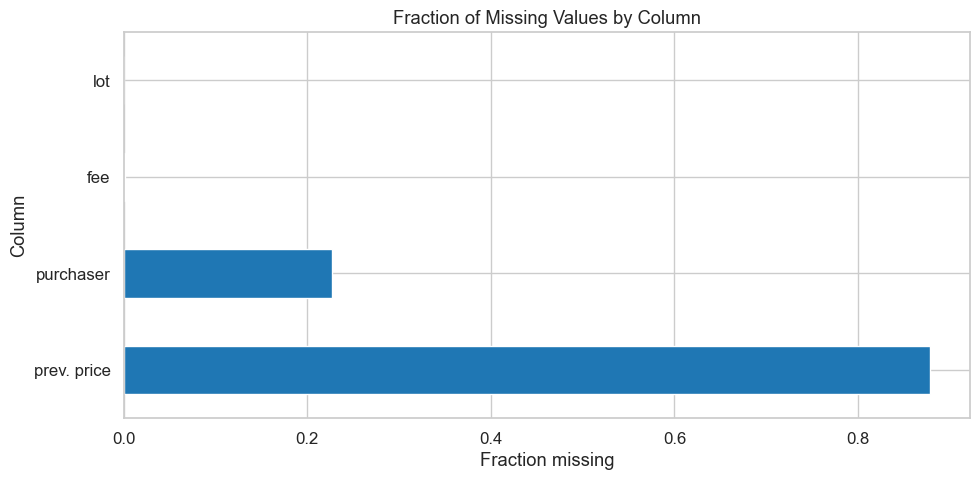

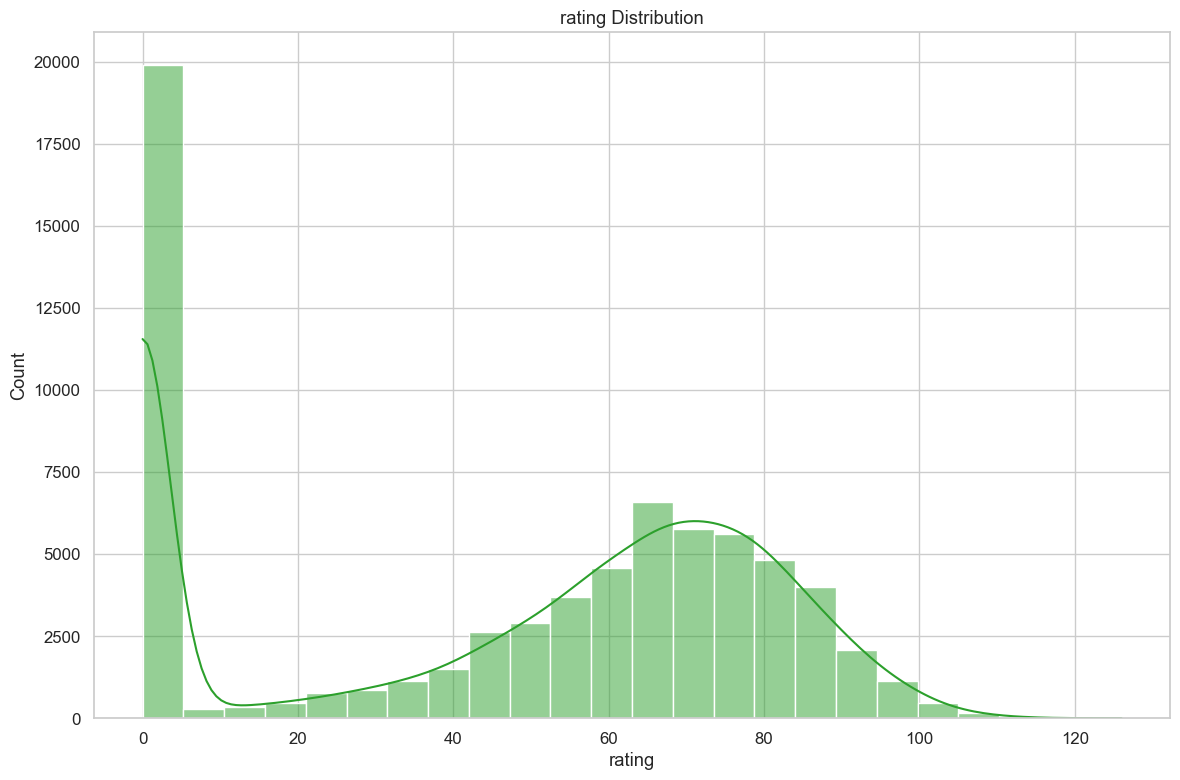

<Figure size 1200x700 with 0 Axes>

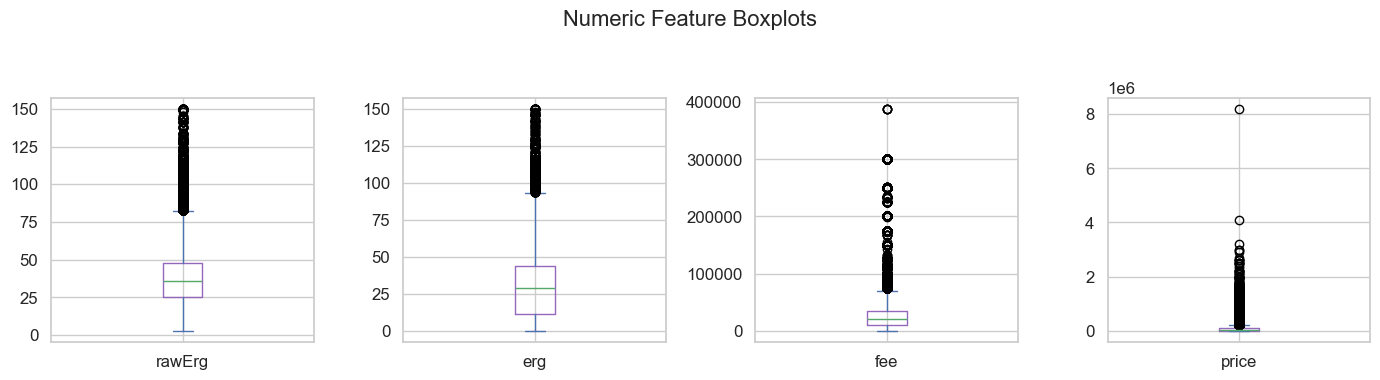

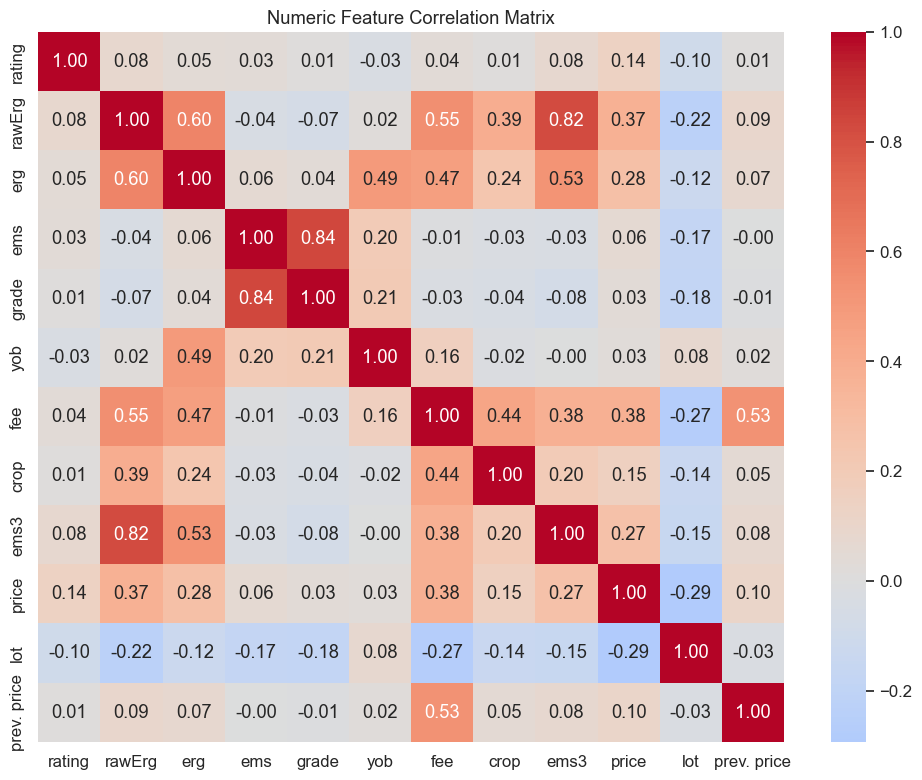

/var/folders/m6/wqgw_v5x3tq4t4q1zm2fc5f80000gn/T/ipykernel_5365/1629813008.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette='tab20')


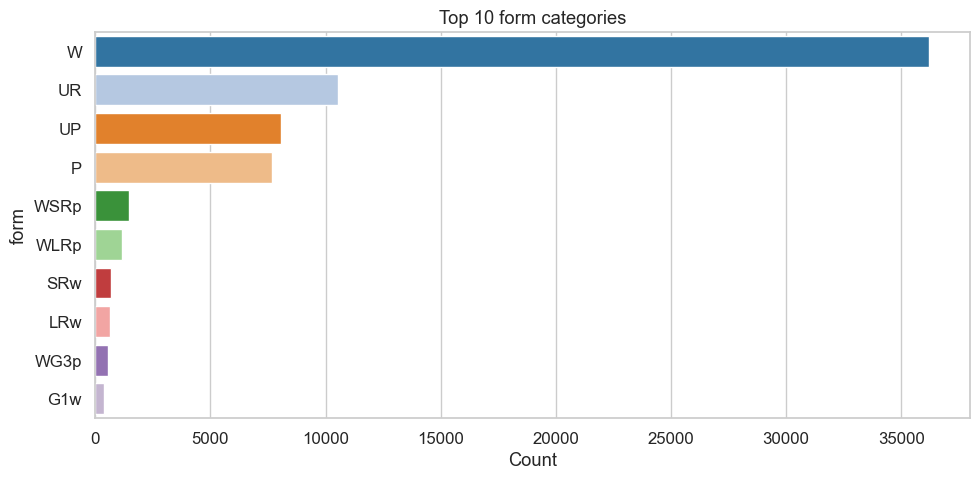

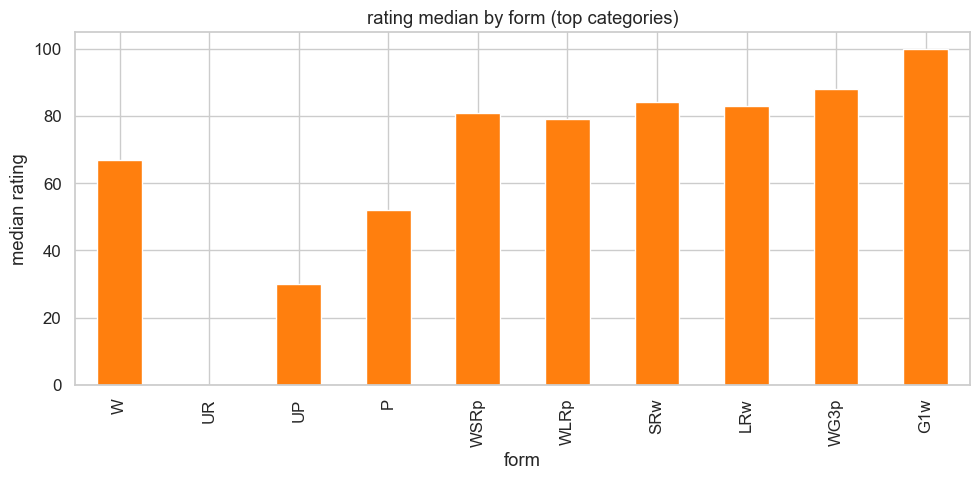

/var/folders/m6/wqgw_v5x3tq4t4q1zm2fc5f80000gn/T/ipykernel_5365/1629813008.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette='tab20')


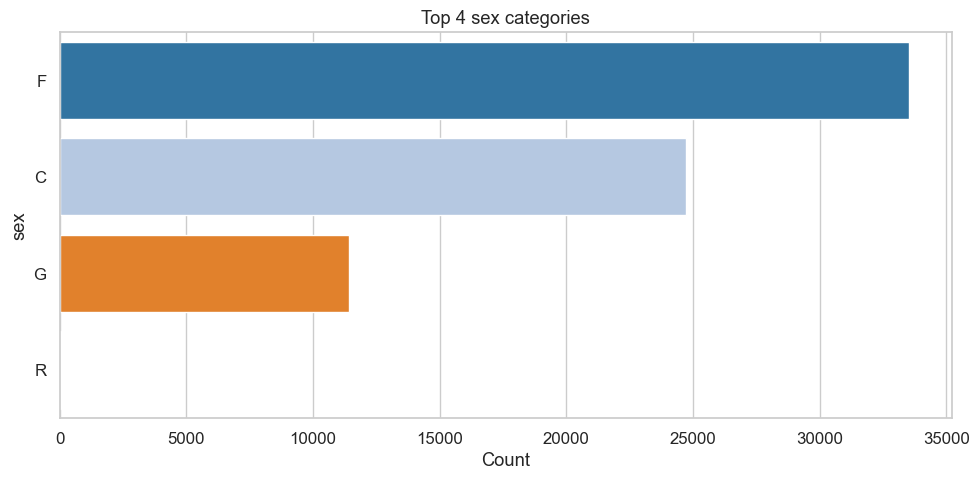

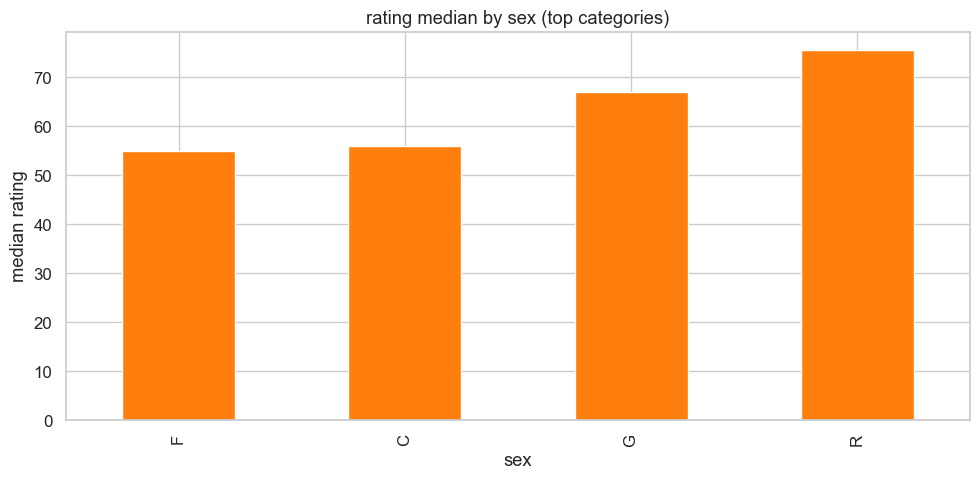

/var/folders/m6/wqgw_v5x3tq4t4q1zm2fc5f80000gn/T/ipykernel_5365/1629813008.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette='tab20')


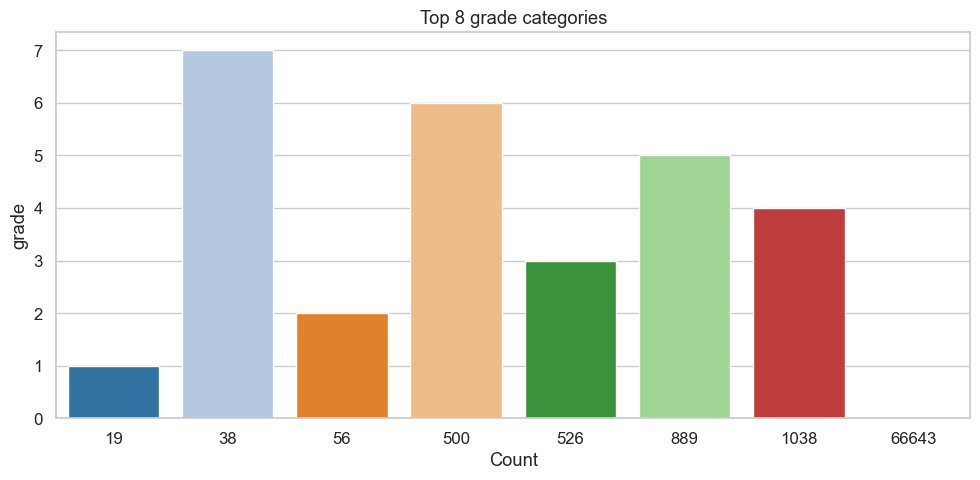

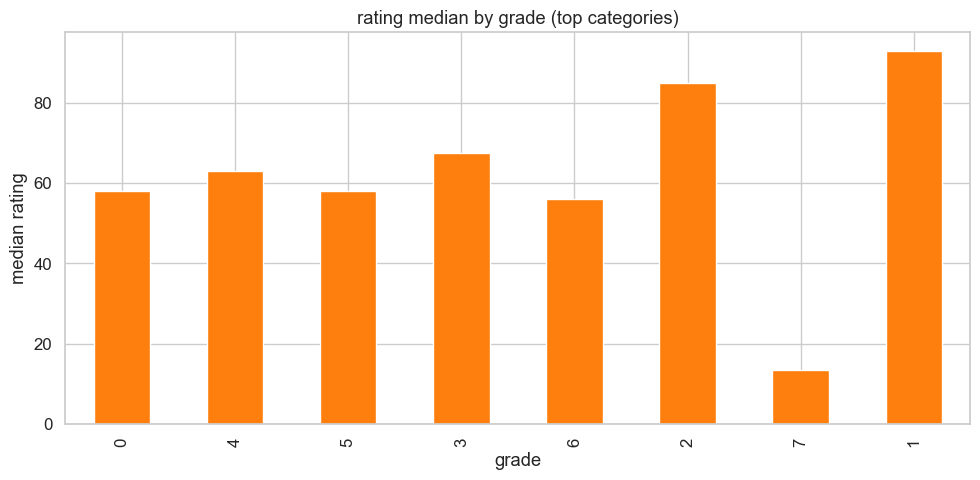

/var/folders/m6/wqgw_v5x3tq4t4q1zm2fc5f80000gn/T/ipykernel_5365/1629813008.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette='tab20')


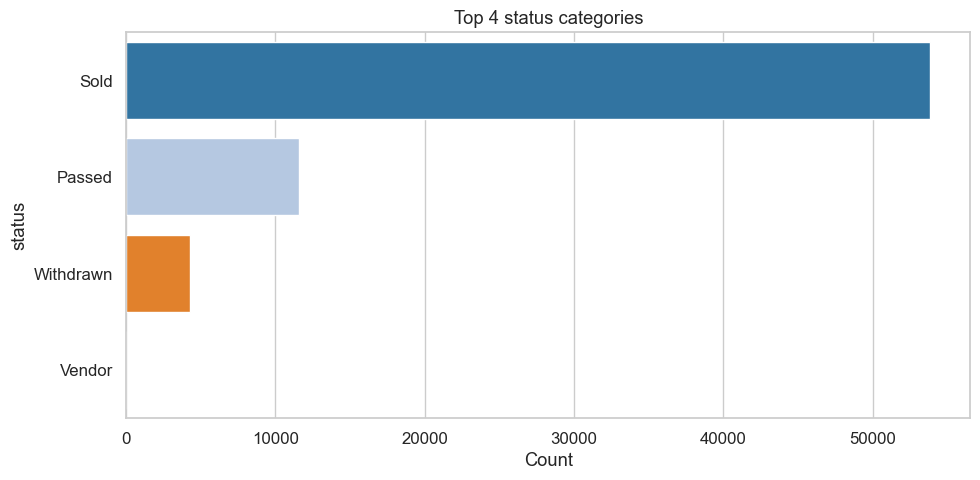

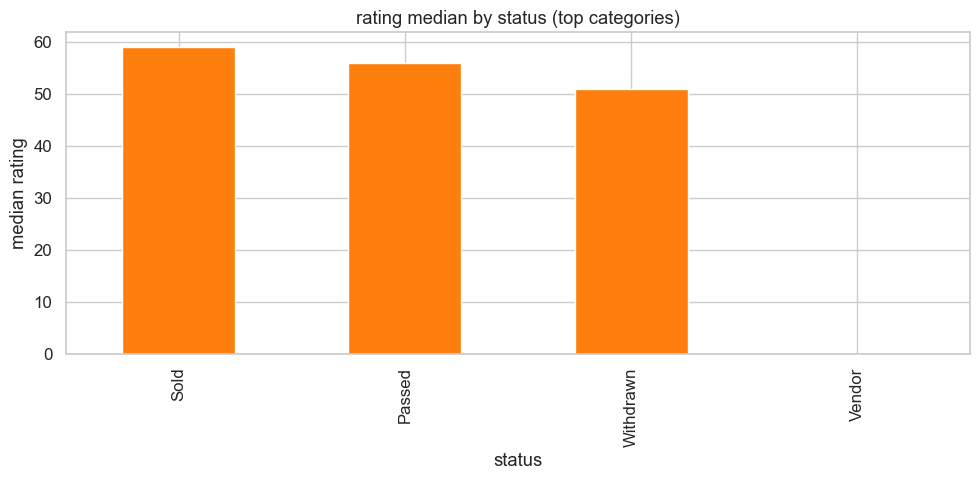

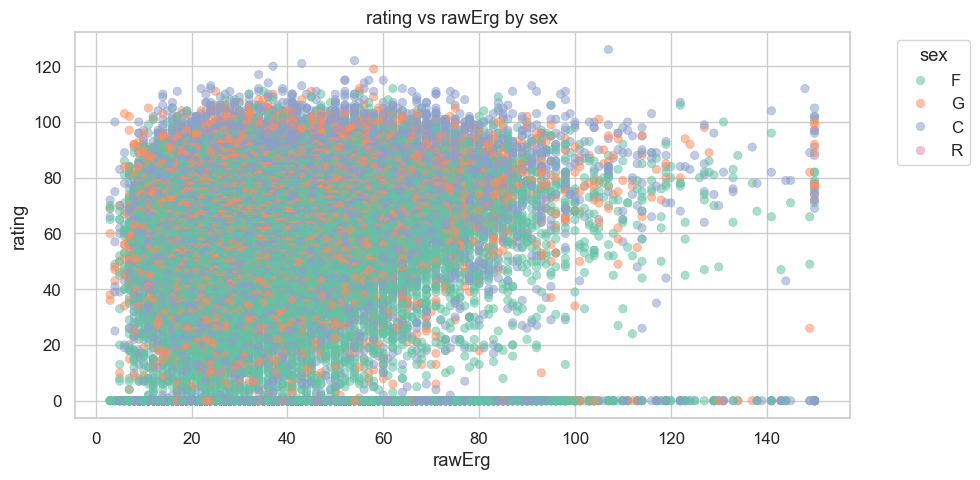


Numeric completeness:
rating         1.000000
rawErg         1.000000
erg            1.000000
ems            1.000000
grade          1.000000
yob            1.000000
crop           1.000000
ems3           1.000000
price          1.000000
lot            0.999871
fee            0.998594
prev. price    0.121534
dtype: float64

--- quick insight summary ---
1) High missingness in some financial/story fields (e.g., price, prev. price) may require imputation or exclusion.
2) strong correlation between rawErg and erg indicates redundancy; choose one for modeling or keep both for gradient boosters with regularization.
3) rating has a broad numeric distribution with heavy concentration near lower values and many zero or missing entries, which may require resampling or target engineering.
4) several categorical columns are high-cardinality (e.g., sire, dam) and may benefit from embedding-like encoding for MLP or target encoding for tree models.
5) sex and form may be useful as low-cardinality c

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)

# Load data (notebooks path is /notebooks; dataset path is in project root /data)
path = '../data/horseData.csv'
raw = pd.read_csv(path)

# Clean numeric conversions for analysis
num_cols = ['rating', 'rawErg', 'erg', 'ems', 'grade', 'yob', 'fee', 'price', 'prev. price']
for col in num_cols:
    if col in raw.columns:
        raw[col] = raw[col].astype(str).str.replace(r"[^0-9.-]", '', regex=True)
        raw.loc[raw[col] == '', col] = np.nan
        raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Basic overview
print('Shape:', raw.shape)
print('Numeric features:', [c for c in raw.select_dtypes(include='number').columns])
print('Missing values (top 20):\n', raw.isna().sum().sort_values(ascending=False).head(20))
print('\nSample rows:')
raw.head()

# Put core target and id info
if 'rating' in raw.columns:
    target = 'rating'
else:
    target = raw.columns[0]

# Missing values chart
plt.figure(figsize=(10, 5))
missing = raw.isna().mean().sort_values(ascending=False)
missing[missing > 0].plot.barh(color='tab:blue')
plt.title('Fraction of Missing Values by Column')
plt.xlabel('Fraction missing')
plt.ylabel('Column')
plt.tight_layout()
plt.show()

# Numeric distribution
numeric = raw.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.histplot(numeric[target].dropna(), kde=True, color='tab:green', bins=24)
plt.title(f'{target} Distribution')
plt.xlabel(target)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplots for key nums to assess outliers
plt.figure(figsize=(12, 7))
cols = ['rawErg', 'erg', 'fee', 'price']
valid_cols = [c for c in cols if c in raw.columns]
if valid_cols:
    raw[valid_cols].plot(kind='box', subplots=True, layout=(1, len(valid_cols)), sharey=False, figsize=(14, 4), boxprops=dict(color='tab:purple'))
    plt.suptitle('Numeric Feature Boxplots')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Correlation heatmap for numeric variables
corr = numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Categorical distributions and relationship with rating
cats = ['form', 'sex', 'grade', 'status']
category_cols = [c for c in cats if c in raw.columns]
for c in category_cols:
    plt.figure(figsize=(10, 5))
    topn = raw[c].value_counts().nlargest(10)
    sns.barplot(x=topn.values, y=topn.index, palette='tab20')
    plt.title(f'Top {len(topn)} {c} categories')
    plt.xlabel('Count')
    plt.ylabel(c)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    grouped = raw[[c, target]].dropna().groupby(c)[target].median().loc[topn.index]
    grouped.plot(kind='bar', color='tab:orange')
    plt.title(f'{target} median by {c} (top categories)')
    plt.ylabel(f'median {target}')
    plt.tight_layout()
    plt.show()

# Target vs strong numeric features: erg, rawErg
if {'erg', 'rawErg', target}.issubset(raw.columns):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=raw, x='rawErg', y='rating', alpha=0.55, hue='sex', palette='Set2', edgecolor=None)
    plt.title('rating vs rawErg by sex')
    plt.xlabel('rawErg')
    plt.ylabel('rating')
    plt.legend(title='sex', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Evaluate numeric completeness for modeling
numeric_completeness = numeric.notna().mean().sort_values(ascending=False)
print('\nNumeric completeness:')
print(numeric_completeness)

# Provide summary statements for strengths/weaknesses
print('\n--- quick insight summary ---')
print('1) High missingness in some financial/story fields (e.g., price, prev. price) may require imputation or exclusion.')
print('2) strong correlation between rawErg and erg indicates redundancy; choose one for modeling or keep both for gradient boosters with regularization.')
print('3) rating has a broad numeric distribution with heavy concentration near lower values and many zero or missing entries, which may require resampling or target engineering.')
print('4) several categorical columns are high-cardinality (e.g., sire, dam) and may benefit from embedding-like encoding for MLP or target encoding for tree models.')
print('5) sex and form may be useful as low-cardinality categorical predictors; early boxplots show noticeable differences in rating by sex and form categories.')
